# 4. Model Fine-Tuning

Fine-tunes the three transformer models on both tasks (6 runs total):

| Model | Why it is included |
|-------|--------------------|
| DistilBERT | compressed model - the speed/efficiency end of the spectrum |
| RoBERTa | optimised BERT pre-training - the accuracy end |
| DeBERTa | disentangled attention - state-of-the-art architecture |

Training setup (matches the paper's methodology): AdamW, learning rate 2e-5 with 6%
warm-up, **same effective batch size (64) for every model** via gradient accumulation,
early stopping on the validation set (patience 2), fixed seed 42.

> `QUICK_TEST = True` runs everything on a small sample in ~15 minutes to verify the
> notebook. Set it to `False` for the real full-data experiments (several hours -
> run overnight, keep the laptop plugged in with the lid open).

In [1]:
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from datasets import load_from_disk, Sequence, Value
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay)
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, DataCollatorWithPadding,
                          EarlyStoppingCallback, set_seed)

QUICK_TEST = False      # True = fast pipeline check, False = real experiments

SEED, MAX_LENGTH = 42, 64
LEARNING_RATE, WARMUP, DECAY, PATIENCE = 2e-5, 0.06, 0.01, 2
PROCESSED, MODELS_DIR, RESULTS = "../data/processed", "../models", "../results"
os.makedirs(RESULTS, exist_ok=True)

device = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# model -> (checkpoint, per-device batch, gradient accumulation)  batch*accum = 64
MODELS = {
    "distilbert": ("distilbert-base-uncased", 64, 1),
    "roberta":    ("roberta-base",            32, 2),
    "deberta":    ("../models/deberta-base-local"          # local copy of microsoft/deberta-base
                   if os.path.exists("../models/deberta-base-local")
                   else "microsoft/deberta-base", 16, 4),
}

TASKS = {
    "sentiment": {"data": "tweeteval_sentiment", "num_labels": 3, "multi_label": False,
                  "max_epochs": 4, "label_names": ["negative", "neutral", "positive"]},
    "emotion":   {"data": "goemotions", "num_labels": 28, "multi_label": True,
                  "max_epochs": 6, "label_names": None},   # read from dataset below
}

device: mps


In [2]:
# load the processed datasets (made by data_preprocessing.ipynb)
data = {t: load_from_disk(os.path.join(PROCESSED, cfg["data"])) for t, cfg in TASKS.items()}
TASKS["emotion"]["label_names"] = data["emotion"]["train"].features["labels"].feature.names

if QUICK_TEST:
    for t in data:
        for split in data[t]:
            n = 800 if split == "train" else 400
            data[t][split] = data[t][split].shuffle(seed=SEED).select(range(min(n, len(data[t][split]))))
    print("QUICK_TEST: running on small samples")

for t in data:
    print(t, {k: len(v) for k, v in data[t].items()})

sentiment {'train': 45615, 'test': 12284, 'validation': 2000}
emotion {'train': 43410, 'validation': 5426, 'test': 5427}


In [3]:
# ---- tokenisation and label preparation ----
def multi_hot(ids, n):
    v = [0.0] * n
    for i in ids:
        v[i] = 1.0
    return v

def prepare(task, tokenizer):
    cfg = TASKS[task]
    def encode(batch):
        enc = tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)
        if cfg["multi_label"]:
            enc["labels"] = [multi_hot(ids, cfg["num_labels"]) for ids in batch["labels"]]
        else:
            enc["labels"] = batch["label"]
        return enc
    ds = data[task].map(encode, batched=True, remove_columns=data[task]["train"].column_names)
    if cfg["multi_label"]:
        # keep the labels as floats - the multi-label loss (BCE) needs that
        ds = ds.cast_column("labels", Sequence(Value("float32")))
    return ds

In [4]:
# ---- evaluation metrics (macro-averaged, because the classes are imbalanced) ----
def single_label_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, preds),
            "precision_macro": precision_score(labels, preds, average="macro", zero_division=0),
            "recall_macro": recall_score(labels, preds, average="macro", zero_division=0),
            "f1_macro": f1_score(labels, preds, average="macro", zero_division=0)}

def multi_label_metrics(eval_pred, threshold=0.5):
    logits, labels = eval_pred
    probs = 1 / (1 + np.exp(-logits))
    preds = (probs >= threshold).astype(int)
    labels = labels.astype(int)
    return {"accuracy": accuracy_score(labels, preds),   # exact-match accuracy
            "precision_macro": precision_score(labels, preds, average="macro", zero_division=0),
            "recall_macro": recall_score(labels, preds, average="macro", zero_division=0),
            "f1_macro": f1_score(labels, preds, average="macro", zero_division=0)}

def tune_threshold(logits, labels):
    """With 28 rare labels a fixed 0.5 cut-off predicts almost nothing.
    Standard practice: choose the threshold on the VALIDATION set."""
    best_t, best_f1 = 0.5, -1
    for t in np.arange(0.05, 0.55, 0.05):
        f1 = multi_label_metrics((logits, labels), float(t))["f1_macro"]
        if f1 > best_f1:
            best_t, best_f1 = round(float(t), 2), f1
    print(f"   tuned threshold: {best_t} (validation macro-F1 {best_f1:.4f})")
    return best_t

In [5]:
# ---- the fine-tuning function (one model on one task) ----
CSV = os.path.join(RESULTS, "experiments.csv")

def train_and_evaluate(model_key, task):
    cfg = TASKS[task]
    checkpoint, batch, accum = MODELS[model_key]
    run = f"{model_key}_{task}"
    print(f"\n===== {run} =====")
    set_seed(SEED)

    tokenizer = AutoTokenizer.from_pretrained(checkpoint)
    ds = prepare(task, tokenizer)
    model = AutoModelForSequenceClassification.from_pretrained(
        checkpoint, num_labels=cfg["num_labels"],
        problem_type="multi_label_classification" if cfg["multi_label"]
                     else "single_label_classification")

    args = TrainingArguments(
        output_dir=f"{MODELS_DIR}/checkpoints/{run}",
        num_train_epochs=2 if QUICK_TEST else cfg["max_epochs"],
        per_device_train_batch_size=batch,
        gradient_accumulation_steps=accum,           # same effective batch (64) for all models
        per_device_eval_batch_size=batch,
        learning_rate=LEARNING_RATE, warmup_ratio=WARMUP, weight_decay=DECAY,
        eval_strategy="epoch", save_strategy="epoch", save_total_limit=1,
        load_best_model_at_end=True,                 # restore the best epoch at the end
        metric_for_best_model="loss" if cfg["multi_label"] else "f1_macro",
        greater_is_better=not cfg["multi_label"],
        logging_steps=50, seed=SEED, report_to="none")

    trainer = Trainer(model=model, args=args,
                      train_dataset=ds["train"], eval_dataset=ds["validation"],
                      data_collator=DataCollatorWithPadding(tokenizer),
                      compute_metrics=multi_label_metrics if cfg["multi_label"] else single_label_metrics,
                      callbacks=[EarlyStoppingCallback(early_stopping_patience=PATIENCE)])

    t0 = time.time()
    trainer.train()
    minutes = (time.time() - t0) / 60

    # learning curve
    hist = pd.DataFrame(trainer.state.log_history)
    fig, ax = plt.subplots(figsize=(6, 3.5))
    if "loss" in hist:
        tr = hist.dropna(subset=["loss"]); ax.plot(tr["epoch"], tr["loss"], label="training loss")
    if "eval_loss" in hist:
        ev = hist.dropna(subset=["eval_loss"]); ax.plot(ev["epoch"], ev["eval_loss"], "o-", label="validation loss")
    ax.set_xlabel("epoch"); ax.legend(); ax.set_title(f"Learning curve - {run}")
    plt.tight_layout(); plt.savefig(f"{RESULTS}/curve_{run}.png", dpi=150); plt.show()

    # final test-set evaluation
    threshold = 0.5
    if cfg["multi_label"]:
        val = trainer.predict(ds["validation"])
        threshold = tune_threshold(val.predictions, val.label_ids)
    pred = trainer.predict(ds["test"])
    if cfg["multi_label"]:
        scores = multi_label_metrics((pred.predictions, pred.label_ids), threshold)
    else:
        scores = single_label_metrics((pred.predictions, pred.label_ids))
        cm = confusion_matrix(pred.label_ids, np.argmax(pred.predictions, axis=-1))
        fig, ax = plt.subplots(figsize=(5, 5))
        ConfusionMatrixDisplay(cm, display_labels=cfg["label_names"]).plot(
            ax=ax, cmap="Blues", colorbar=False)
        ax.set_title(f"Confusion matrix - {run}")
        plt.tight_layout(); plt.savefig(f"{RESULTS}/cm_{run}.png", dpi=150); plt.show()

    # save the fine-tuned model (used by evaluation.ipynb)
    trainer.save_model(f"{MODELS_DIR}/{run}")
    tokenizer.save_pretrained(f"{MODELS_DIR}/{run}")

    row = {"model": model_key, "task": task, "quick_test": QUICK_TEST,
           "epochs_trained": round(trainer.state.epoch, 1), "threshold": threshold,
           "train_minutes": round(minutes, 1),
           "texts_per_second": round(pred.metrics["test_samples_per_second"], 1),
           **{k: round(v, 4) for k, v in scores.items()}}
    table = pd.DataFrame([row])
    if os.path.exists(CSV):
        table = pd.concat([pd.read_csv(CSV), table], ignore_index=True)
    table.to_csv(CSV, index=False)

    # free the GPU memory before the next run - without this, models pile up
    # in memory and the later runs crash with an out-of-memory error
    import gc
    del trainer, model
    gc.collect()
    if device == "mps":
        torch.mps.empty_cache()

    print(row)

[skip] distilbert_sentiment already done
[skip] distilbert_emotion already done
[skip] roberta_sentiment already done

===== roberta_emotion =====


Map:   0%|          | 0/5426 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/5426 [00:00<?, ? examples/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


/opt/anaconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


...

/opt/anaconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


/opt/anaconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


/opt/anaconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


/opt/anaconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


/opt/anaconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


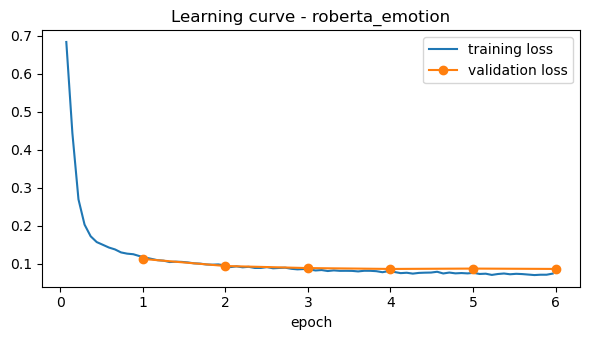

/opt/anaconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


   tuned threshold: 0.2 (validation macro-F1 0.4611)


/opt/anaconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


{'model': 'roberta', 'task': 'emotion', 'quick_test': False, 'epochs_trained': 6.0, 'threshold': 0.2, 'train_minutes': 33.0, 'texts_per_second': 478.3, 'accuracy': 0.3901, 'precision_macro': 0.439, 'recall_macro': 0.5138, 'f1_macro': 0.4577}

===== deberta_sentiment =====


Map:   0%|          | 0/45615 [00:00<?, ? examples/s]

...

/opt/anaconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.577700,0.581053,0.746000,0.732189,0.738181,0.735056
2,0.491400,0.596556,0.757500,0.758805,0.724833,0.738401
3,0.374100,0.657156,0.743000,0.721587,0.731818,0.726290
4,0.318200,0.713373,0.736500,0.716797,0.729571,0.722546


/opt/anaconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


/opt/anaconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


/opt/anaconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


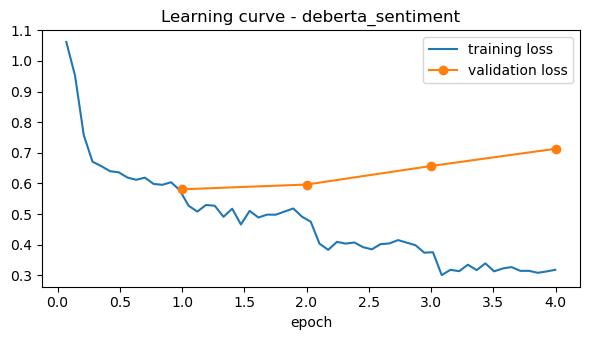

/opt/anaconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


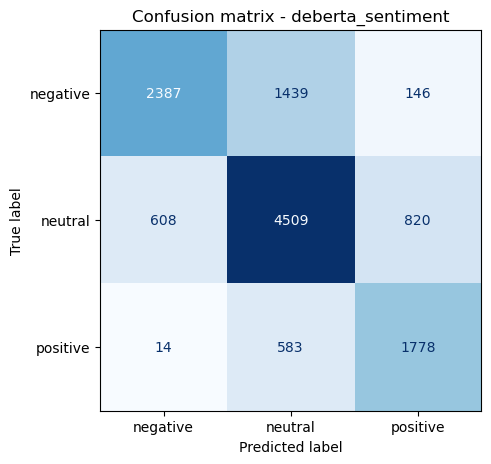

{'model': 'deberta', 'task': 'sentiment', 'quick_test': False, 'epochs_trained': 4.0, 'threshold': 0.5, 'train_minutes': 43.6, 'texts_per_second': 223.5, 'accuracy': 0.7061, 'precision_macro': 0.7105, 'recall_macro': 0.703, 'f1_macro': 0.7006}

===== deberta_emotion =====


Map:   0%|          | 0/43410 [00:00<?, ? examples/s]

Map:   0%|          | 0/5426 [00:00<?, ? examples/s]

Map:   0%|          | 0/5427 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/43410 [00:00<?, ? examples/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.104000,0.096858,0.335053,0.380890,0.172457,0.201405
2,0.085600,0.085217,0.439550,0.559872,0.325355,0.380750
3,0.077100,0.083774,0.465168,0.574663,0.385312,0.437208
4,0.072400,0.084735,0.465721,0.552377,0.405743,0.454622
5,0.064000,0.086456,0.464062,0.566719,0.418915,0.458972


/opt/anaconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


/opt/anaconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


/opt/anaconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


/opt/anaconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


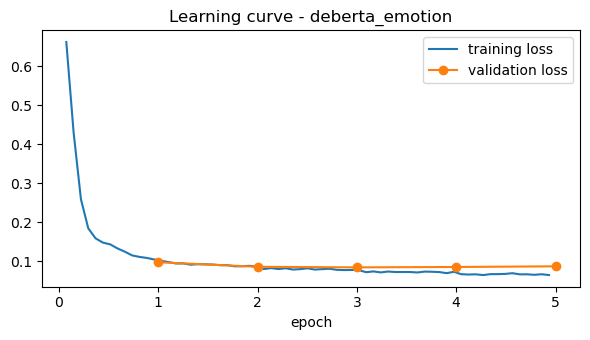

/opt/anaconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


   tuned threshold: 0.3 (validation macro-F1 0.4743)


/opt/anaconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


{'model': 'deberta', 'task': 'emotion', 'quick_test': False, 'epochs_trained': 5.0, 'threshold': 0.3, 'train_minutes': 43.1, 'texts_per_second': 260.7, 'accuracy': 0.4456, 'precision_macro': 0.4752, 'recall_macro': 0.4937, 'f1_macro': 0.4691}


,model,task,quick_test,epochs_trained,threshold,train_minutes,texts_per_second,accuracy,precision_macro,recall_macro,f1_macro
0,distilbert,sentiment,False,4.0,0.5,16.2,758.7,0.6915,0.6874,0.6901,0.6881
1,distilbert,emotion,False,6.0,0.2,16.9,928.2,0.3790,0.4231,0.4895,0.4383
2,roberta,sentiment,False,4.0,0.5,28.5,439.8,0.7200,0.7104,0.7328,0.7196
3,roberta,emotion,False,6.0,0.2,33.0,478.3,0.3901,0.4390,0.5138,0.4577
4,deberta,sentiment,False,4.0,0.5,43.6,223.5,0.7061,0.7105,0.7030,0.7006
5,deberta,emotion,False,5.0,0.3,43.1,260.7,0.4456,0.4752,0.4937,0.4691


In [6]:
# ---- run all six experiments (skips runs already in the results file) ----
done = set()
if os.path.exists(CSV):
    prev = pd.read_csv(CSV)
    prev = prev[prev["quick_test"] == QUICK_TEST]
    done = set(zip(prev["model"], prev["task"]))

for model_key in ["distilbert", "roberta", "deberta"]:
    for task in ["sentiment", "emotion"]:
        if (model_key, task) in done:
            print(f"[skip] {model_key}_{task} already done")
        else:
            train_and_evaluate(model_key, task)

pd.read_csv(CSV)